In [ ]:
# Check all installed packages in current environment
if False:
    import pkg_resources

    dists = [str(d).replace(" ","==") for d in pkg_resources.working_set]
    dists.sort()
    for i in dists:
        print(i)

# Check all local variables
if False:
    locals()
    
# Check instance variables
if False:
    vars(store_)

In [126]:
import pandas as pd
import numpy as np
from sklearn import impute
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt


In [255]:
def plot_signal(signal_data):
    has_nan = np.isnan(np.min(signal_data))  # np.isnan(signal_data.min())
    
    fig, axes = plt.subplots(1, 1, figsize=(6, 6))
    axes.plot(signal_data)
    title = "Has nan values" if has_nan else "Has no nan values"
    axes.set_title(title)
    plt.show()

# Single signal imputation

## Reference signal

In [223]:
if False:
    X = [
        [np.nan, 2],
        [6, np.nan],
        [7, 6],
        [np.nan, 3],
        [8, np.nan]
    ]
else:
    X = np.load("thomson_scattering__n_e__30421.npy")[:, 0]  # [time, profile]

# np.isnan(signal_values.min())
# np.isnan(X.min())

print(f"X.shape: {X.shape}")
print(f"has_nan(X): {np.isnan(X.min())}")


X.shape: (146,)
has_nan(X): True


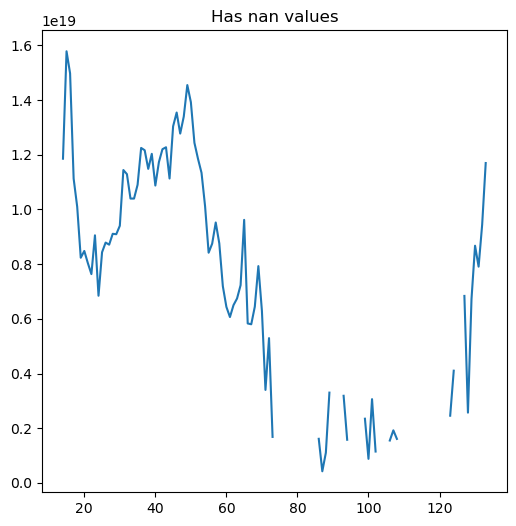

In [241]:
plot_signal(X)

## SK Learn - SimpleImputer

C:\Users\I85464754\miniforge3\envs\fairmast-data-preprocessing\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  74  75  76  78
  80  81  82  84  85  90  92  95  96  97  98 103 104 105 109 110 112 113
 114 115 117 118 120 122 125 126 134 135 136 137 138 139 140 141 142 143
 144 145]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


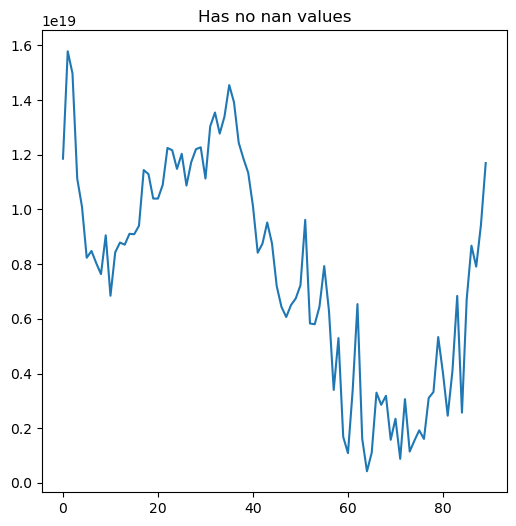

In [242]:
if True:
    # Via fit-then-transform
    
    imp_fit_then_tran = SimpleImputer(missing_values=np.nan, strategy='mean')
    imp_fit_then_tran.fit([X])
    # SimpleImputer()
    
    x_imp = imp_fit_then_tran.transform([X])
else:
    # Via fit-with-transform
    
    imp_fit_with_tran = SimpleImputer(strategy="mean")
    x_imp = imp_fit_with_tran.fit_transform([X])
    
plot_signal(x_imp[0])

## Pandas - Foward/backward fill

In [256]:
x_df_fow_bac = pd.DataFrame(X)
# x_df_fow_bac

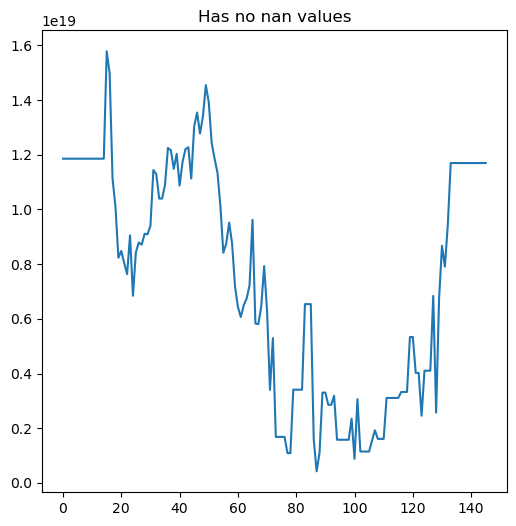

In [257]:
x_imp = x_df_fow_bac.ffill().bfill()
plot_signal(x_imp)


## Pandas - Value fill

In [258]:
x_df_val = pd.DataFrame(X)
# x_df_val

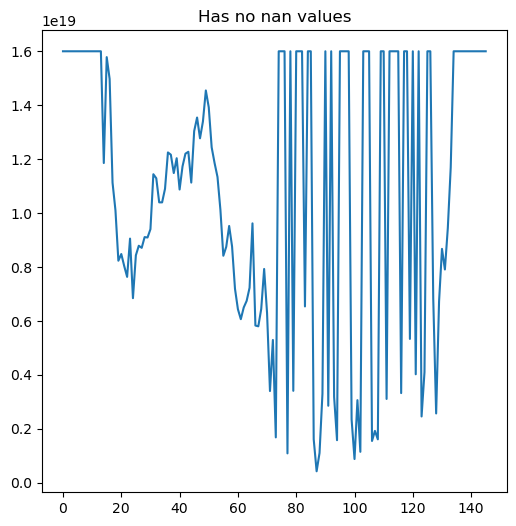

In [259]:
tar_val = 1.6e19
x_imp = x_df_val.fillna(tar_val)
plot_signal(x_imp)


## Pandas - Interpolation fill

In [260]:
x_df_interp = pd.DataFrame(X)
# x_df_interp

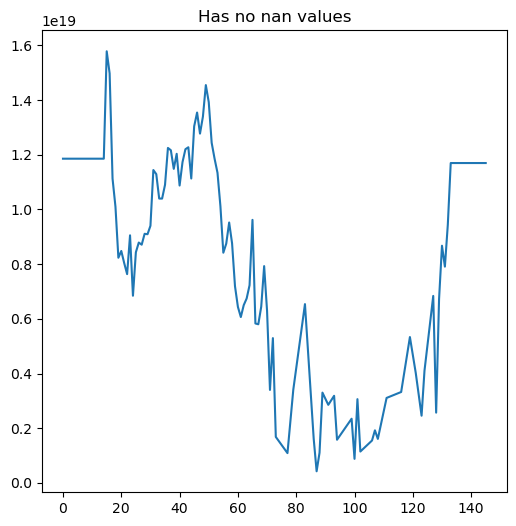

In [261]:
x_imp = x_df_interp.interpolate(
    limit_direction="both"
)
plot_signal(x_imp)

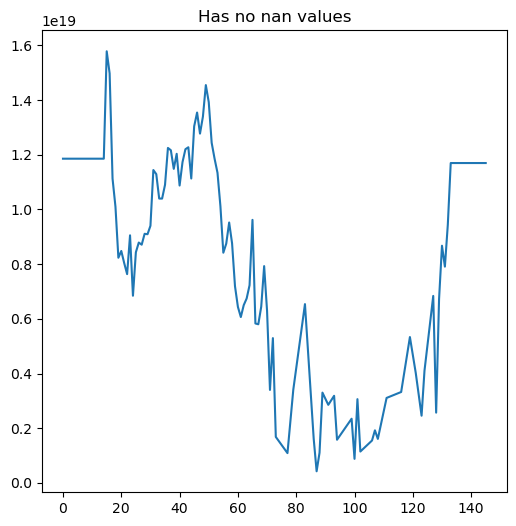

In [262]:
x_imp = x_df_interp.interpolate(
    method="values",
    limit_direction="both"
)
plot_signal(x_imp)


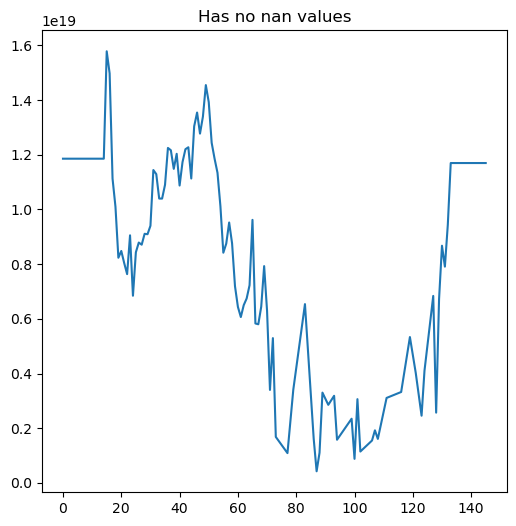

In [263]:
x_imp = x_df_interp.interpolate(
    method="linear",
    limit_direction="both"
)
plot_signal(x_imp)

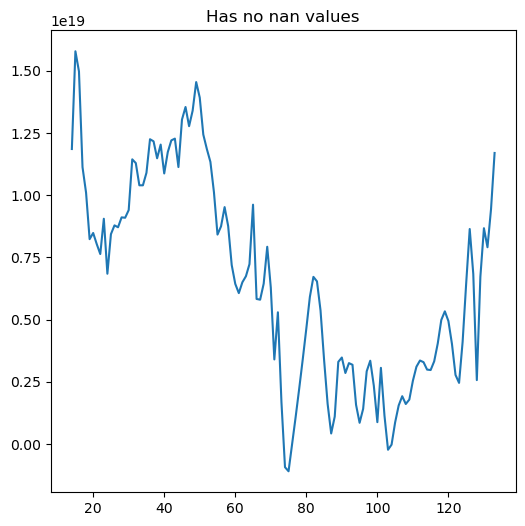

In [264]:
x_imp = x_df_interp.interpolate(
    method="quadratic",
    limit_direction="both"  # It does not help.
)
plot_signal(x_imp)


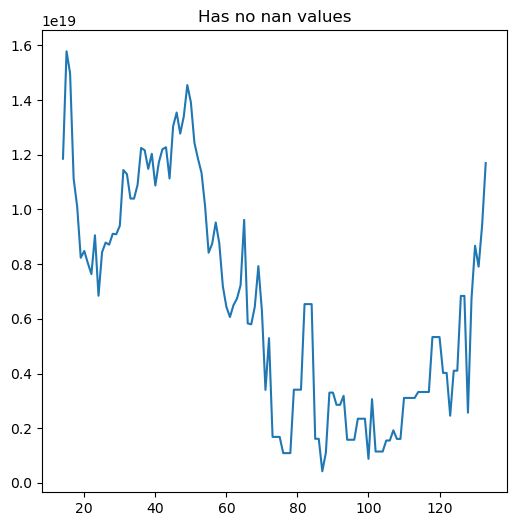

In [265]:
x_imp = x_df_interp.interpolate(
    method="nearest",
    limit_direction="both"  # It does not help.
)
plot_signal(x_imp)


In [268]:
x_imp

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
141,NaN
142,NaN
143,NaN
144,NaN


C:\Users\I85464754\miniforge3\envs\fairmast-data-preprocessing\Lib\site-packages\scipy\interpolate\_polyint.py:451: UserWarning: 90 degrees provided, degrees higher than about thirty cause problems with numerical instability with 'KroghInterpolator'
  P = KroghInterpolator(xi, yi, axis=axis)


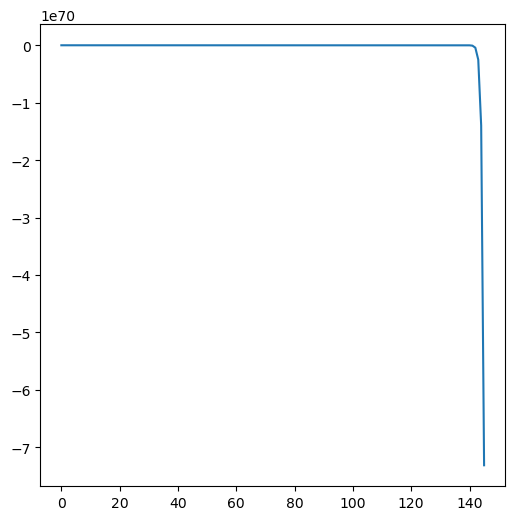

In [204]:
x_imp = x_df_interp.interpolate(
    method="krogh",
    limit_direction="both"
)
plot_signal(x_imp)


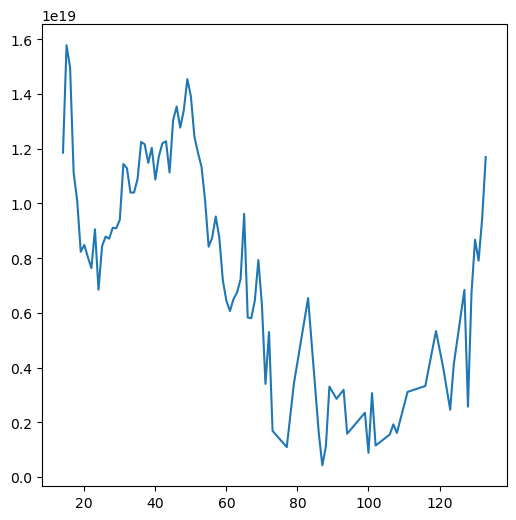

In [205]:
x_imp = x_df_interp.interpolate(
    method="from_derivatives",
    limit_direction="both",
)
plot_signal(x_imp)


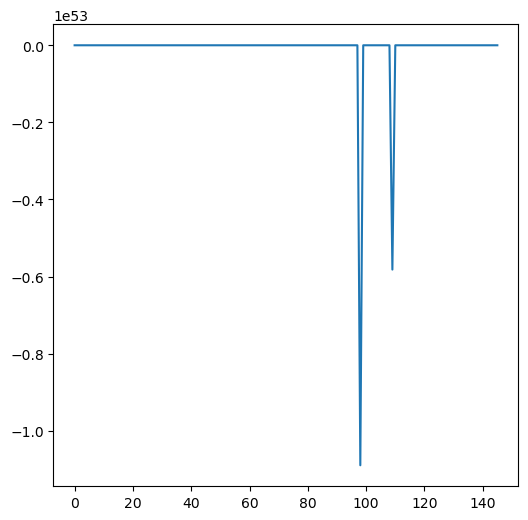

In [206]:
x_imp = x_df_interp.interpolate(
    method="barycentric",
    limit_direction="both"
)
plot_signal(x_imp)


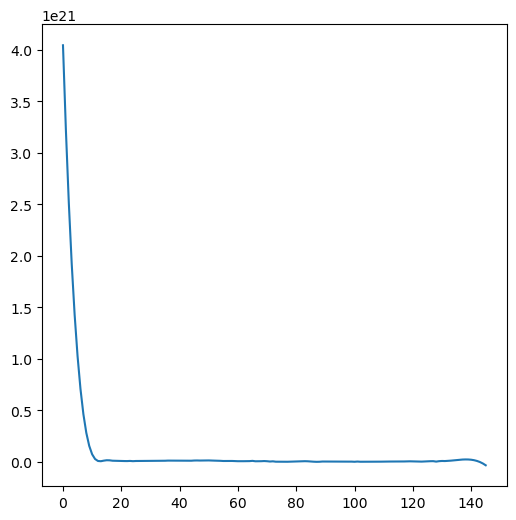

In [207]:
x_imp = x_df_interp.interpolate(
    method="pchip",
    limit_direction="both"
)
plot_signal(x_imp)


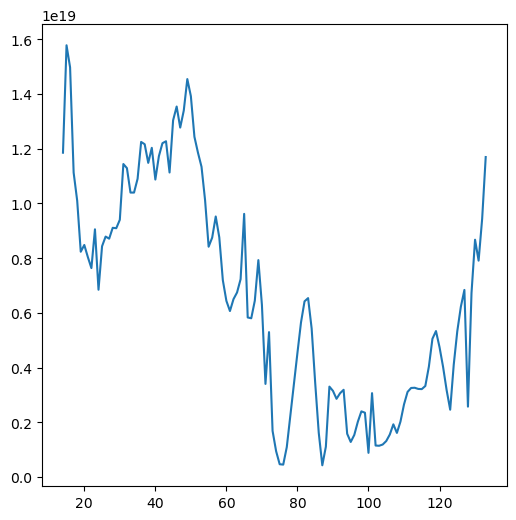

In [208]:
x_imp = x_df_interp.interpolate(
    method="akima",
    limit_direction="both"  # It does not help.
)
plot_signal(x_imp)


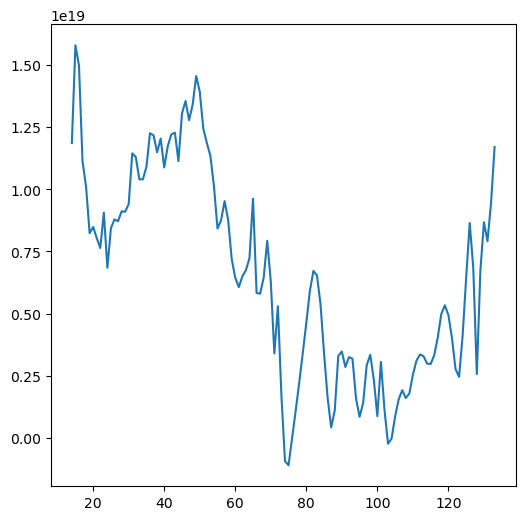

In [209]:
x_imp = x_df_interp.interpolate(
    method="polynomial",
    order=2,
    limit_direction="both"  # It does not help.
)
plot_signal(x_imp)


C:\Users\I85464754\miniforge3\envs\fairmast-data-preprocessing\Lib\site-packages\pandas\core\missing.py:604: UserWarning: 
A theoretically impossible result was found during the iteration
process for finding a smoothing spline with fp = s: s too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)


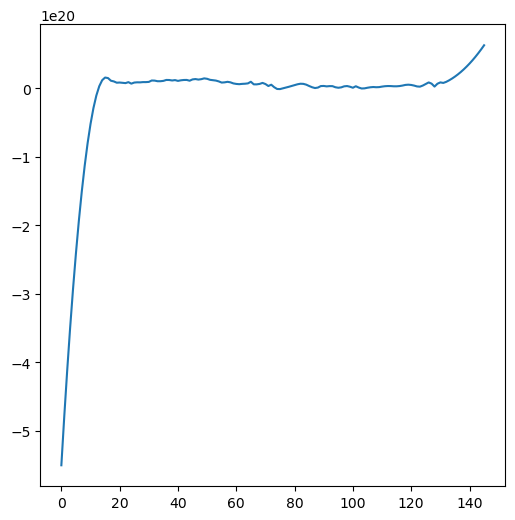

In [210]:
x_imp = x_df_interp.interpolate(
    method="spline",
    order=2,
    limit_direction="both"
)
plot_signal(x_imp)


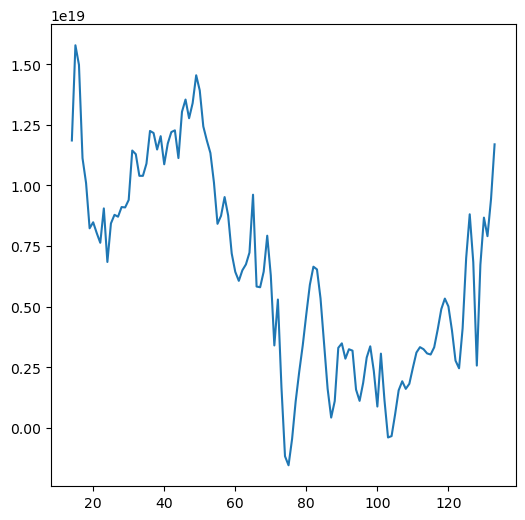

In [211]:
x_imp = x_df_interp.interpolate(method="cubic")
plot_signal(x_imp)


In [52]:
# help(x_df_interp.interpolate)

## Pandas - Replace

In [212]:
x_df_rep = pd.DataFrame(X)
# x_df_rep

In [87]:
x_df_rep.replace(np.nan, 0)

,0,1
0,0.0,2.0
1,6.0,0.0
2,7.0,6.0


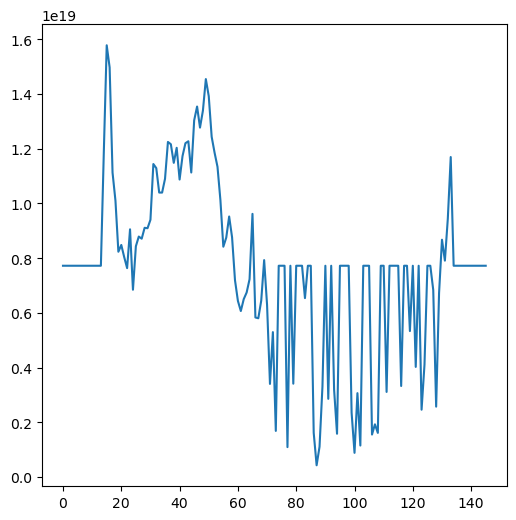

In [213]:
x_imp = x_df_rep.replace(np.nan, x_df_rep.mean())
plot_signal(x_imp)


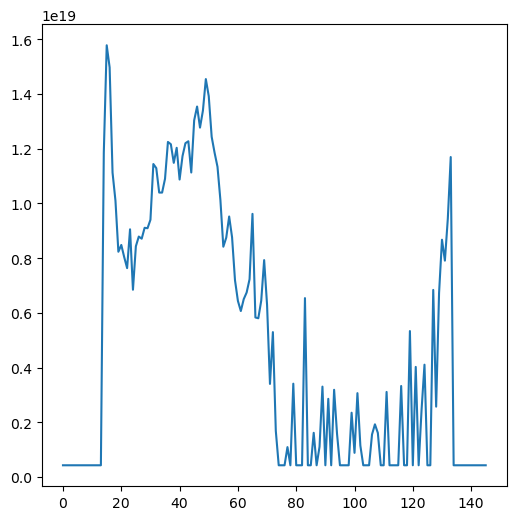

In [214]:
x_imp = x_df_rep.replace(np.nan, x_df_rep.min())
plot_signal(x_imp)


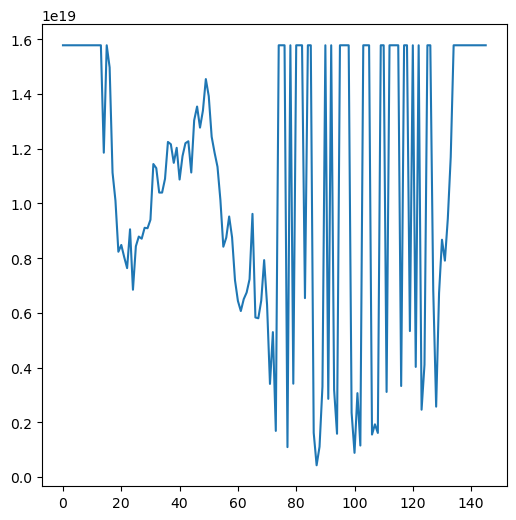

In [215]:
x_imp = x_df_rep.replace(np.nan, x_df_rep.max())
plot_signal(x_imp)


In [217]:
# help(x_df_rep.replace)